# 5 · The Unified Workflow — *From question to a defensible plan*

> **The payoff.** One pipeline, the whole Aurora story: state the causal assumptions → anchor to the
> geo-lift experiments → fit → read the corrected ROAS → **reallocate the budget** → report. The point
> isn't the model; it's the **decision** — and how different it is from the dashboard's.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
from loguru import logger
logger.remove(); logger.add(sys.stderr, level="ERROR")   # quiet framework logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aurora import generate_aurora, CHANNELS, PRODUCTS, PALETTE, CHANNEL_COLORS

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

aurora = generate_aurora()      # the one dataset every chapter shares

## The pipeline

We fold the geo-lift experiments for **all four channels** into the likelihood (Aurora ran a full
incrementality program last year), giving an observational model **anchored to randomized evidence**.

In [2]:
from mmm_framework import BayesianMMM, ModelConfigBuilder, SeasonalityConfigBuilder, TrendConfig, TrendType
from mmm_framework.analysis import MMMAnalyzer
from mmm_framework.calibration import ExperimentMeasurement, ExperimentEstimand

window = (str(aurora.weeks[0].date()), str(aurora.weeks[-1].date()))
experiments = [
    ExperimentMeasurement(ch, window, value=float(aurora.true_roas[ch]), se=0.08,
                          estimand=ExperimentEstimand.ROAS)
    for ch in CHANNELS
]
panel = aurora.base_panel(control_demand=True)
cfg = (ModelConfigBuilder().bayesian_pymc().with_chains(2).with_draws(500).with_tune(500)
       .with_seasonality_builder(SeasonalityConfigBuilder().with_yearly(order=2)).build())

mmm = BayesianMMM(panel, cfg, TrendConfig(type=TrendType.LINEAR), experiments=experiments)
results = mmm.fit(draws=500, tune=500, chains=2, cores=1, random_seed=0)
roi = MMMAnalyzer(mmm).compute_channel_roi().set_index("Channel")["ROI"].loc[CHANNELS]

Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, experiment_Display_roas_3, experiment_Search_roas_1, experiment_Social_roas_2, experiment_TV_roas_0, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


Output()

...

Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

In [3]:
recovered = pd.DataFrame({"true ROAS": aurora.true_roas.loc[CHANNELS], "model ROAS": roi})
display(recovered.round(2))
print("Experiment-anchored model recovers the true ranking:",
      list(recovered["model ROAS"].sort_values(ascending=False).index))

,true ROAS,model ROAS
TV,2.14,2.08
Search,0.66,0.64
Social,0.49,0.46
Display,2.11,2.08


Experiment-anchored model recovers the true ranking: ['Display', 'TV', 'Search', 'Social']


It doesn't just recover the *ranking* — it lands on the true ROAS. Plotted against the truth, every
channel hugs the 45° line.

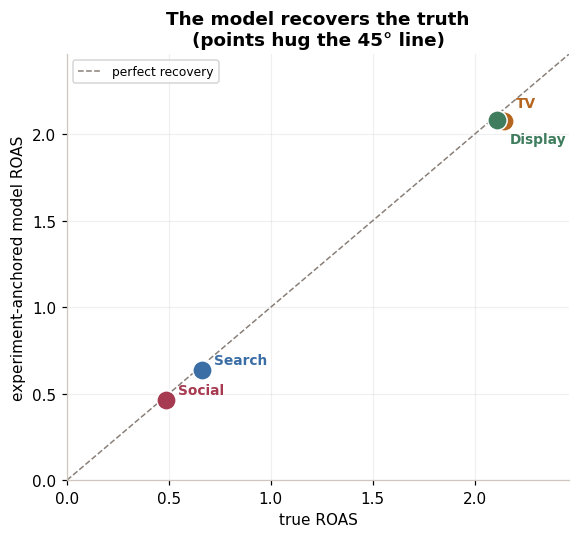

In [4]:
# The experiment-anchored model recovers the truth — points hug the 45° line.
chs = list(CHANNELS)
rec = recovered.loc[chs]
lim = float(max(rec["true ROAS"].max(), rec["model ROAS"].max())) * 1.15
fig, ax = plt.subplots(figsize=(5.4, 5))
ax.plot([0, lim], [0, lim], color=MUTED, ls="--", lw=1, label="perfect recovery")
# Per-channel label offsets so TV & Display (which nearly coincide) don't collide.
_lbl_off = {"TV": (8, 9), "Display": (8, -15), "Search": (8, 4), "Social": (8, 4)}
for ch in chs:
    ax.scatter(rec.loc[ch, "true ROAS"], rec.loc[ch, "model ROAS"], s=160,
               color=CHANNEL_COLORS[ch], edgecolor="white", lw=1, zorder=3)
    ax.annotate(ch, (rec.loc[ch, "true ROAS"], rec.loc[ch, "model ROAS"]),
                xytext=_lbl_off.get(ch, (8, 4)), textcoords="offset points", fontsize=9,
                weight="bold", color=CHANNEL_COLORS[ch])
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("true ROAS"); ax.set_ylabel("experiment-anchored model ROAS")
ax.set_title("The model recovers the truth\n(points hug the 45° line)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## The decision: naive plan vs causal plan

Two planners walk in. **The dashboard planner** funds by correlation — more into Search/Social.
**The causal planner** funds by experiment-anchored ROAS — more into TV/Display. We hold the budget
fixed, shift a slice of it each way, and value each shift at the channels' true ROAS. *(This is a
deliberately stylized, first-order comparison — it values the average dollar and holds saturation
fixed — to show the **direction and order of magnitude**, not a precise forecast.)*

In [5]:
spend = aurora.spend[CHANNELS].sum()                     # current annual spend by channel
pool = 0.25 * spend.sum()                                # budget we're willing to move
naive_corr = pd.Series({c: np.corrcoef(aurora.spend[c], aurora.sales_total)[0, 1] for c in CHANNELS})

def allocate(score):
    # Move the pool toward the top-2 channels by `score`, away from the bottom-2.
    rank = score.sort_values(ascending=False)
    winners, losers = rank.index[:2], rank.index[2:]
    delta = pd.Series(0.0, index=CHANNELS)
    delta[winners] = pool / 2
    delta[losers] = -pool / 2
    return delta

naive_delta  = allocate(naive_corr)     # dashboard: chase correlation
causal_delta = allocate(roi)            # causal: chase experiment-anchored ROAS

# Value each plan against the TRUE ROAS (what revenue the shift actually earns).
naive_lift  = float((naive_delta  * aurora.true_roas.loc[CHANNELS]).sum())
causal_lift = float((causal_delta * aurora.true_roas.loc[CHANNELS]).sum())
print(f"Shift ${pool:,.0f}k of budget (vs leaving it where it is):")
print(f"  Dashboard plan (fund {list(allocate(naive_corr)[allocate(naive_corr)>0].index)}):  "
      f"${naive_lift:+,.0f}k revenue")
print(f"  Causal plan    (fund {list(allocate(roi)[allocate(roi)>0].index)}):  "
      f"${causal_lift:+,.0f}k revenue")
print(f"  → Cost of chasing correlation instead of causal ROAS: ~${causal_lift - naive_lift:,.0f}k/yr (illustrative).")

Shift $3,829k of budget (vs leaving it where it is):
  Dashboard plan (fund ['Search', 'Social']):  $-5,942k revenue
  Causal plan    (fund ['TV', 'Display']):  $+5,942k revenue
  → Cost of chasing correlation instead of causal ROAS: ~$11,884k/yr (illustrative).


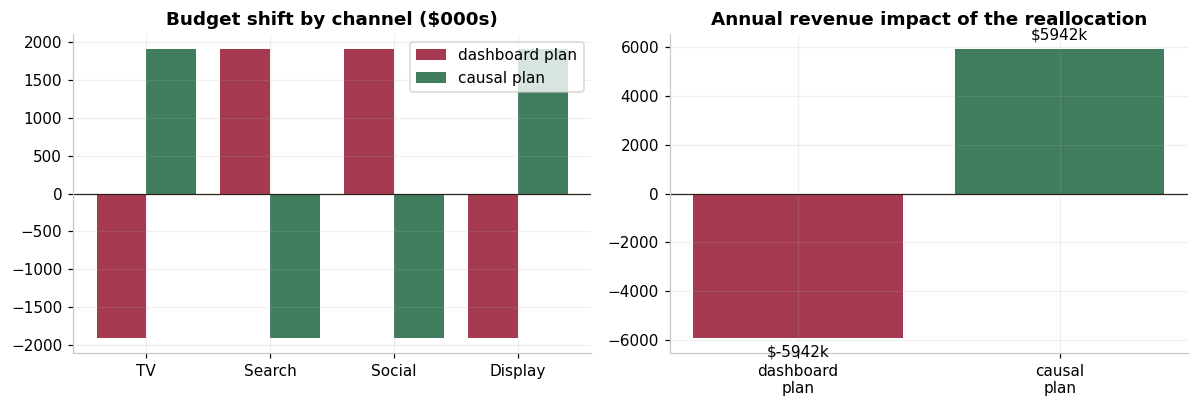

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.arange(len(CHANNELS))
a1.bar(x-0.2, naive_delta, 0.4, label="dashboard plan", color=PALETTE["berry"])
a1.bar(x+0.2, causal_delta, 0.4, label="causal plan", color=PALETTE["leaf"])
a1.set_xticks(x); a1.set_xticklabels(CHANNELS); a1.axhline(0, color=INK, lw=.8)
a1.set_title("Budget shift by channel ($000s)"); a1.legend()
a2.bar(["dashboard\nplan", "causal\nplan"], [naive_lift, causal_lift],
       color=[PALETTE["berry"], PALETTE["leaf"]])
a2.bar_label(a2.containers[0], fmt="$%.0fk", padding=4)
a2.set_title("Annual revenue impact of the reallocation"); a2.axhline(0, color=INK, lw=.8)
plt.tight_layout(); plt.show()

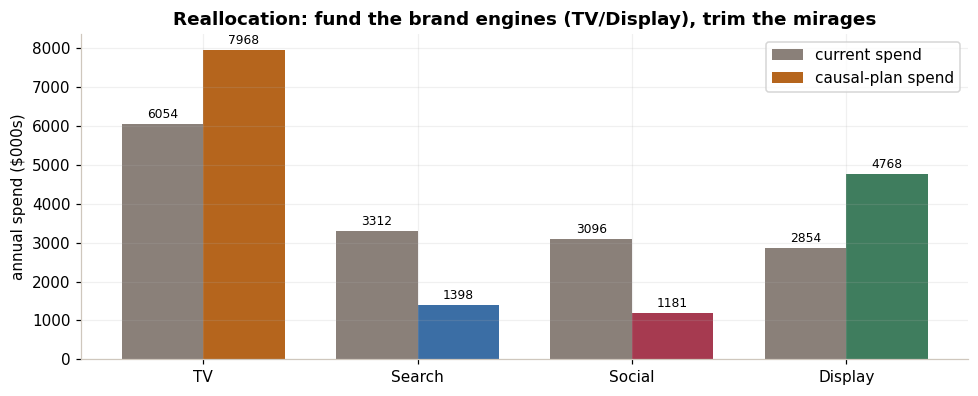

In [7]:
# Current spend vs the causal plan's recommended spend, by channel.
chs = list(CHANNELS)
current = spend.loc[chs]
recommended = (spend + causal_delta).loc[chs]
x = np.arange(len(chs)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 3.7))
b1 = ax.bar(x - w/2, current, w, label="current spend", color=MUTED)
b2 = ax.bar(x + w/2, recommended, w, label="causal-plan spend",
            color=[CHANNEL_COLORS[c] for c in chs])
ax.set_xticks(x); ax.set_xticklabels(chs)
ax.set_ylabel("annual spend ($000s)")
ax.set_title("Reallocation: fund the brand engines (TV/Display), trim the mirages")
ax.bar_label(b1, fmt="%.0f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.0f", padding=2, fontsize=8)
ax.legend()
plt.tight_layout(); plt.show()

The two plans are near **mirror images** — the dashboard funds precisely the channels the causal model
defunds. A real planner wouldn't swing the budget fully inverted, so read the dollar figure as an
*illustrative* upper bound, not a forecast. But the lesson is solid and verified: **chasing correlation
moves money the wrong way**, and the gap between the two directions is the price of getting it wrong.

## Ship the decision

In [8]:
from pathlib import Path
from mmm_framework.reporting import MMMReportGenerator, ReportConfig, ColorScheme, ColorPalette
Path("artifacts").mkdir(exist_ok=True)
report = MMMReportGenerator(
    model=mmm, panel=panel, results=results,
    config=ReportConfig(title="Aurora Coffee Co. — Q3 Plan (experiment-anchored)",
                        client="Aurora Coffee Co.", confidential=True,
                        color_scheme=ColorScheme.from_palette(ColorPalette.CORPORATE)))
print("Final board report:", report.to_html("artifacts/aurora_final_plan.html"))

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


...

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Final board report: artifacts/aurora_final_plan.html


## The Aurora story, in one line

> *A dashboard sees correlations and would have funded a mirage. `mmm_framework` sees a **causal system**
> — confounded spend, a brand-awareness pathway, cannibalizing products — anchors it to **randomized
> experiments**, quantifies the **uncertainty**, and turns it into a **defensible reallocation** worth
> real money.*

| Chapter | What it added |
|---|---|
| 1 · Causality | Made assumptions explicit; proved adjustment isn't enough; **anchored to experiments**. |
| 2 · Base MMM | ROAS & marginal ROAS **with credible intervals**; honest diagnostics. |
| 3 · Extended | TV/Display are **brand engines** (mediation); products **cannibalize**. |
| 4 · Reporting | A **board-ready** deck with the causal assumptions on the table. |
| 5 · Workflow | One pipeline → a reallocation the CFO can sign. |

That's the value of a causal MMM: not a prettier number, a **better decision**.